<a href="https://www.kaggle.com/code/lalit7881/restaurant-market-analysis-82-84-beat?scriptVersionId=353196227" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/zomato-market-analysis/Zomato Restaurant Dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/srisyra02/zomato-market-analysis/Zomato Restaurant Dataset.csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,��stanbul,"Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...",Moda,"Moda, ��stanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [7]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object

In [10]:
df.shape

(9551, 21)

In [11]:
df.nunique

<bound method DataFrame.nunique of       Restaurant ID           Restaurant Name  Country Code              City  \
0           6317637          Le Petit Souffle           162       Makati City   
1           6304287          Izakaya Kikufuji           162       Makati City   
2           6300002    Heat - Edsa Shangri-La           162  Mandaluyong City   
3           6318506                      Ooma           162  Mandaluyong City   
4           6314302               Sambo Kojin           162  Mandaluyong City   
...             ...                       ...           ...               ...   
9546        5915730               Naml۱ Gurme           208         ��stanbul   
9547        5908749              Ceviz A��ac۱           208         ��stanbul   
9548        5915807                     Huqqa           208         ��stanbul   
9549        5916112               A���k Kahve           208         ��stanbul   
9550        5927402  Walter's Coffee Roastery           208         ��stan

In [12]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

## EDA

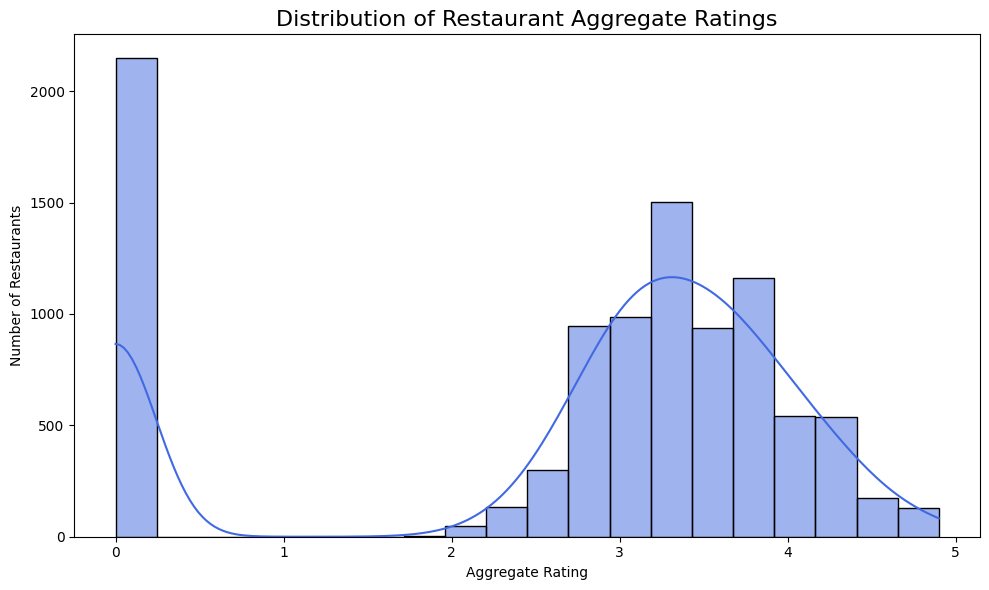

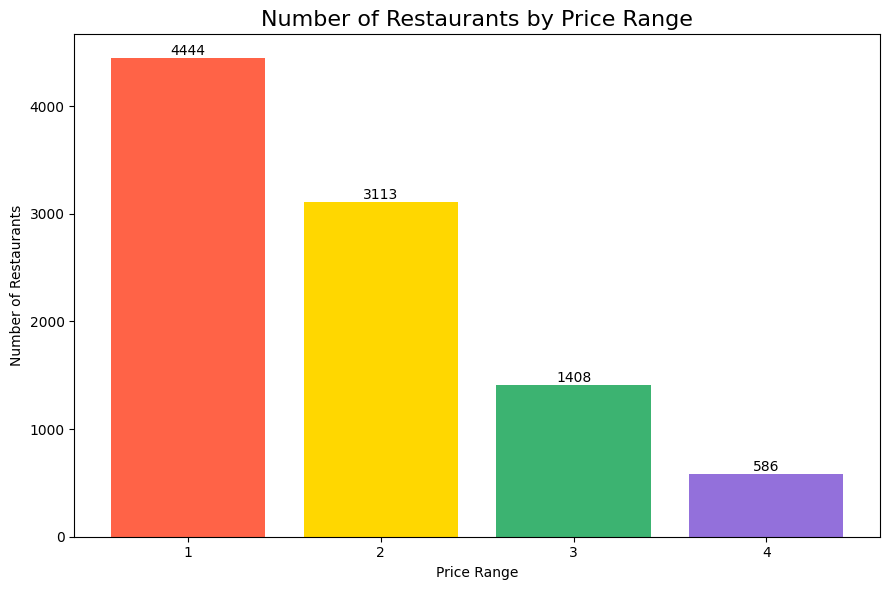

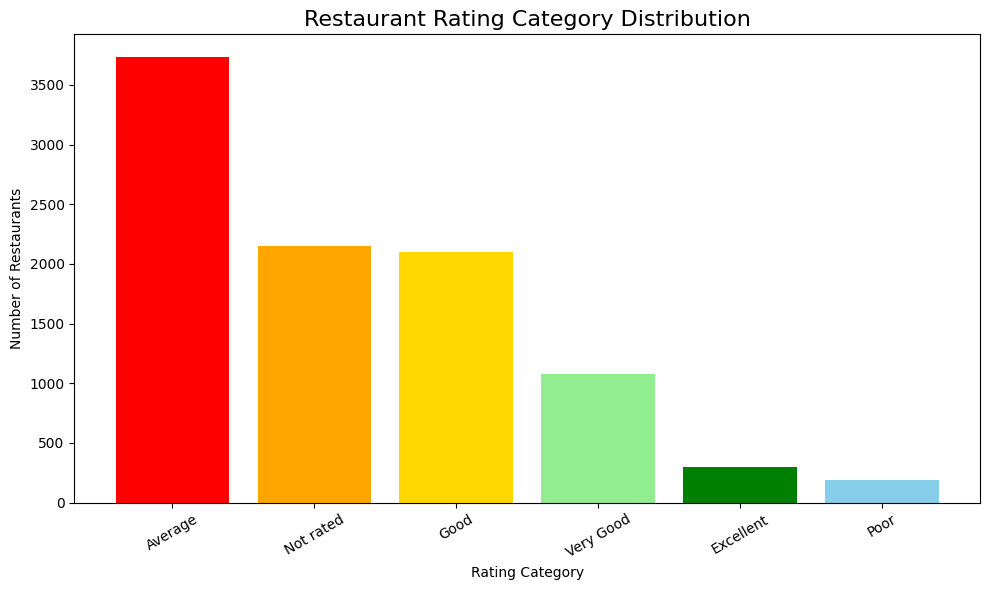

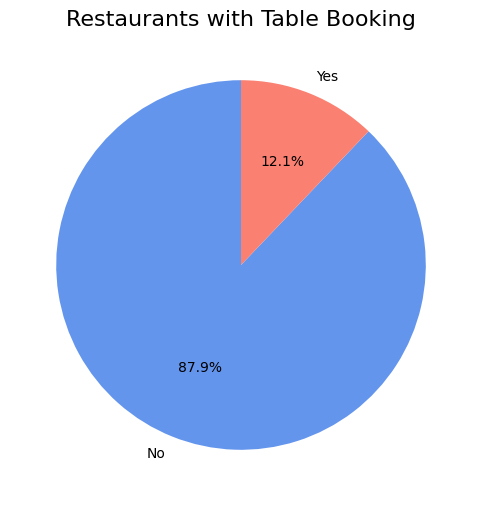

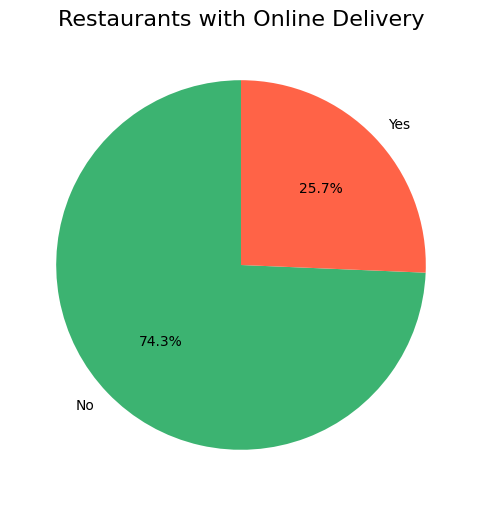

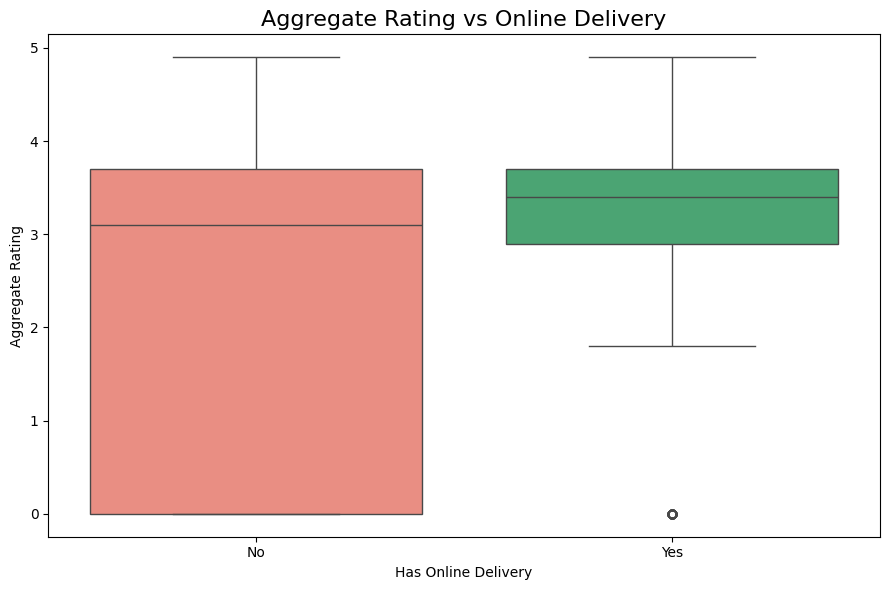

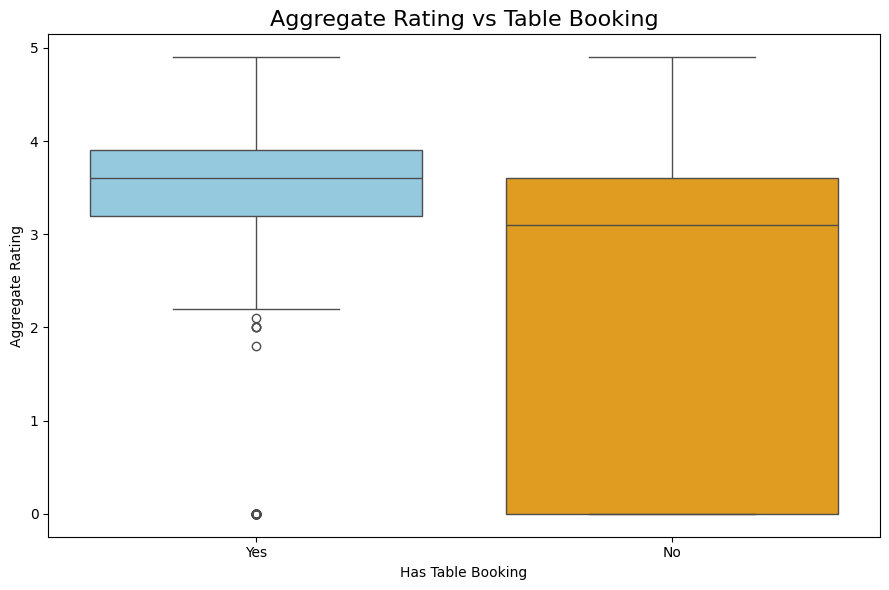

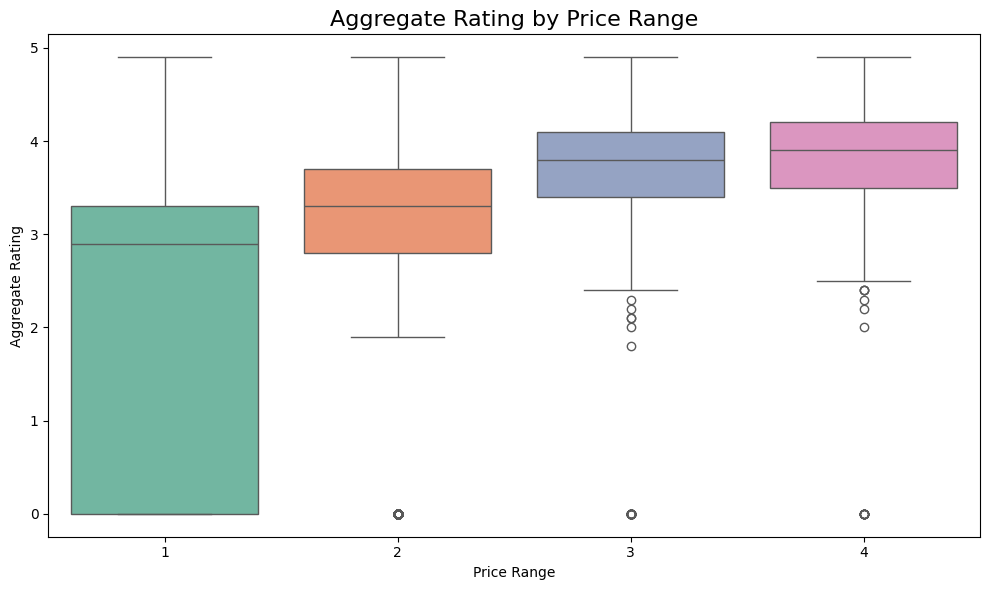

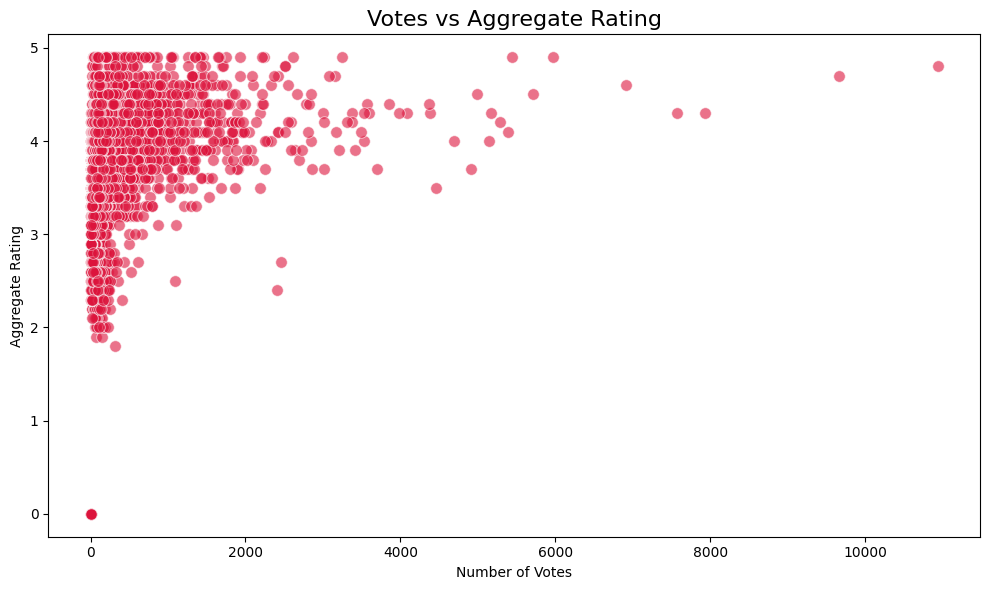

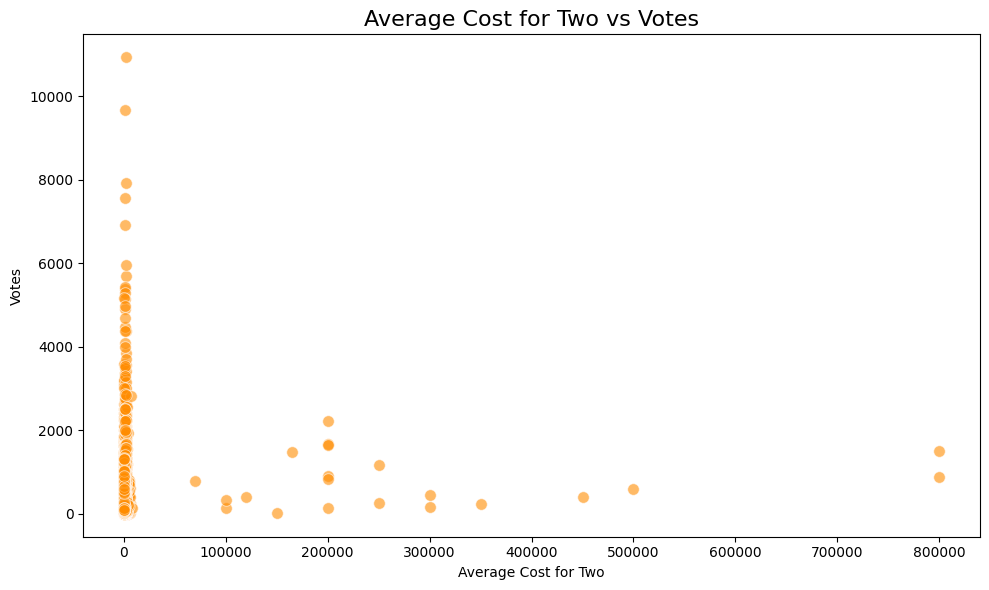

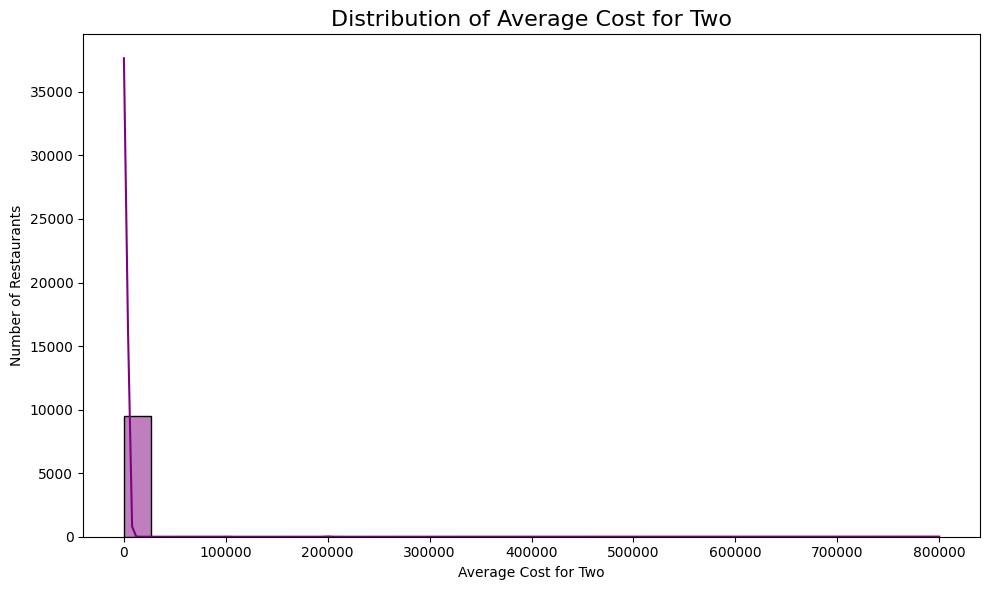

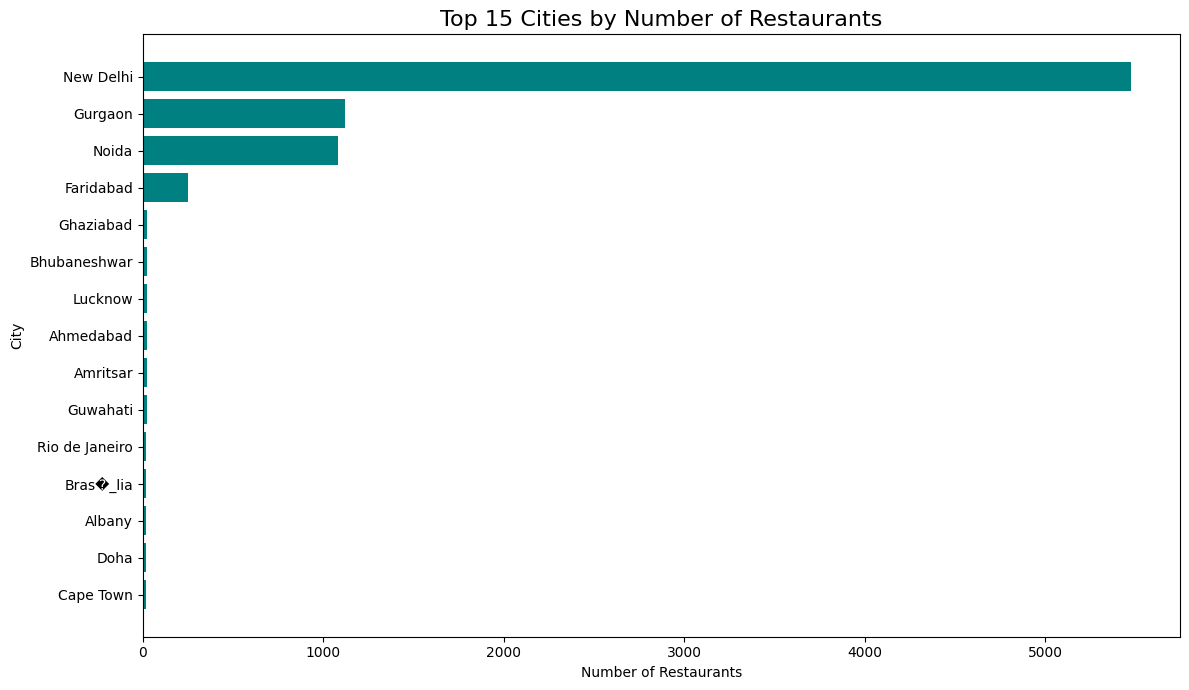

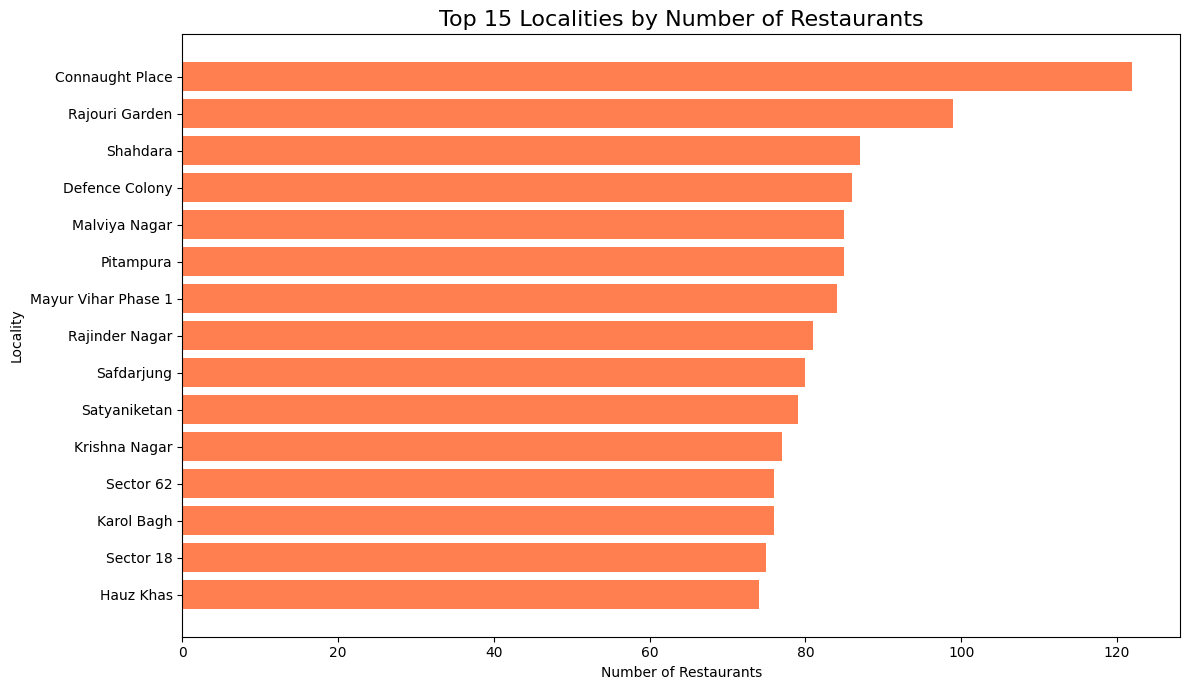

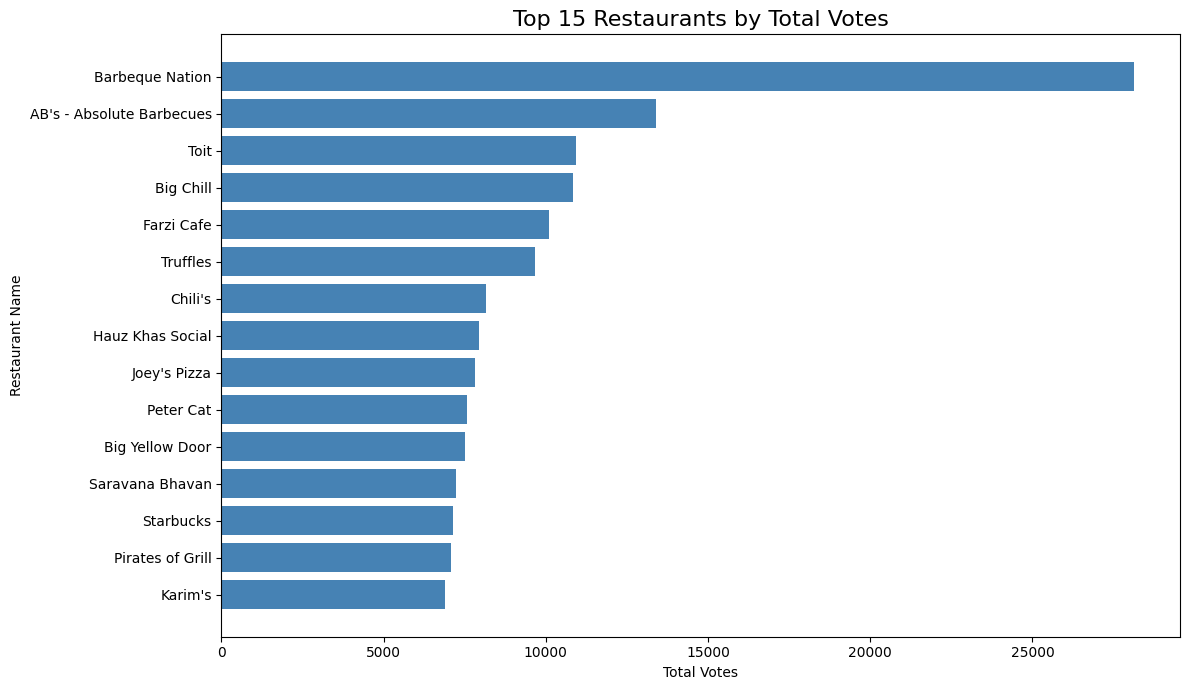

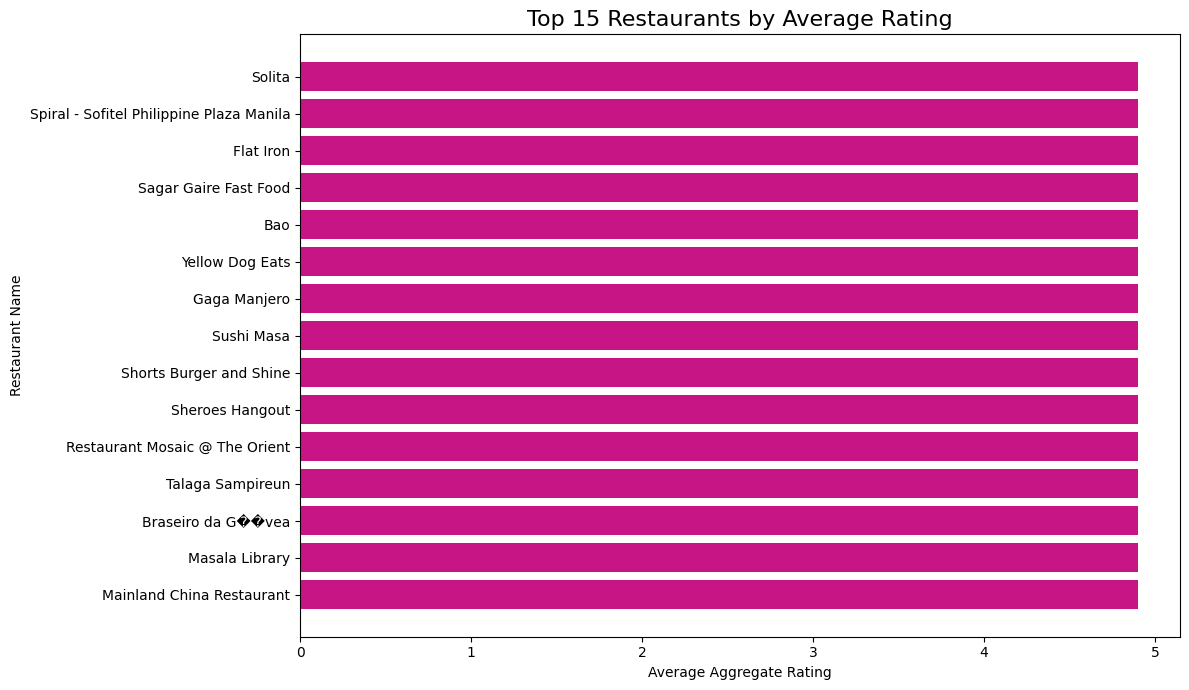

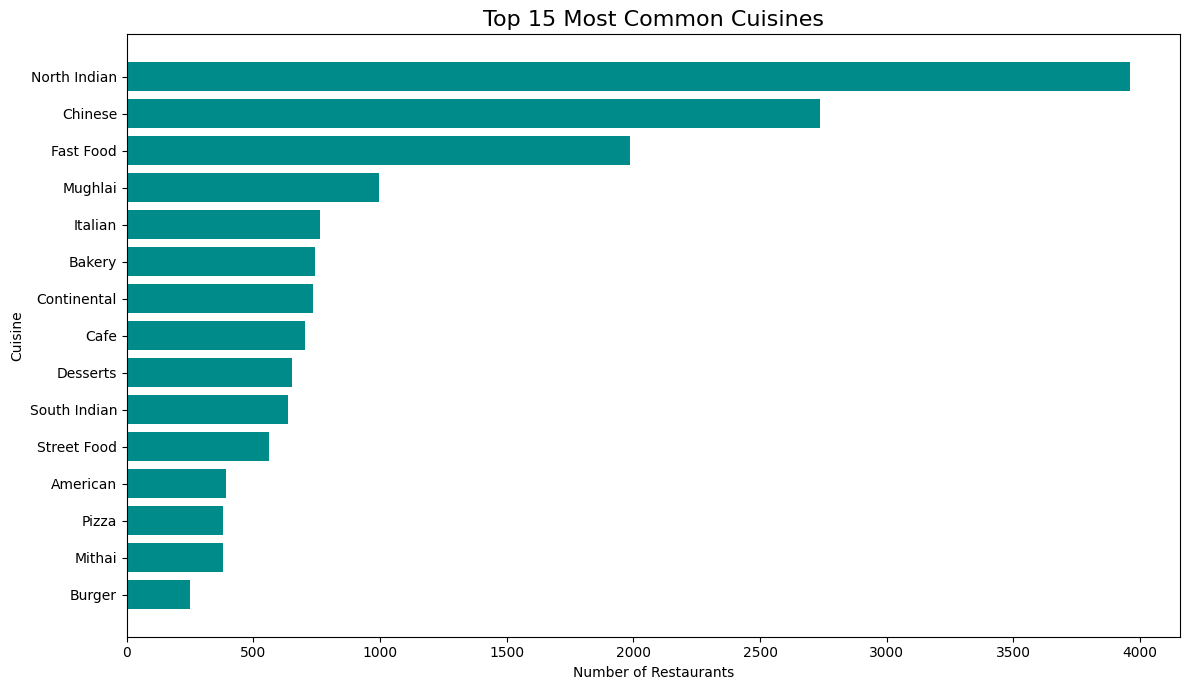

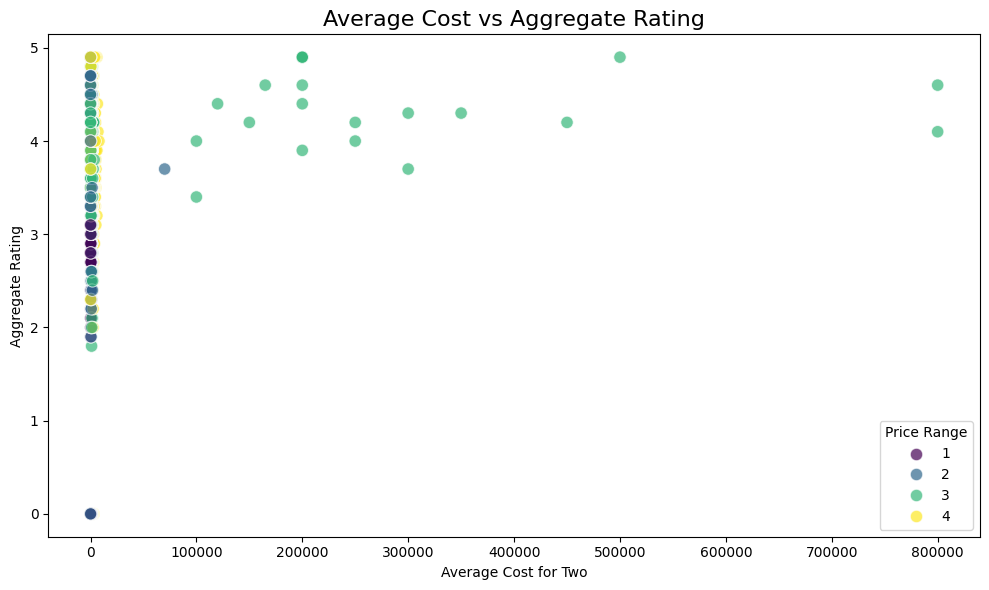

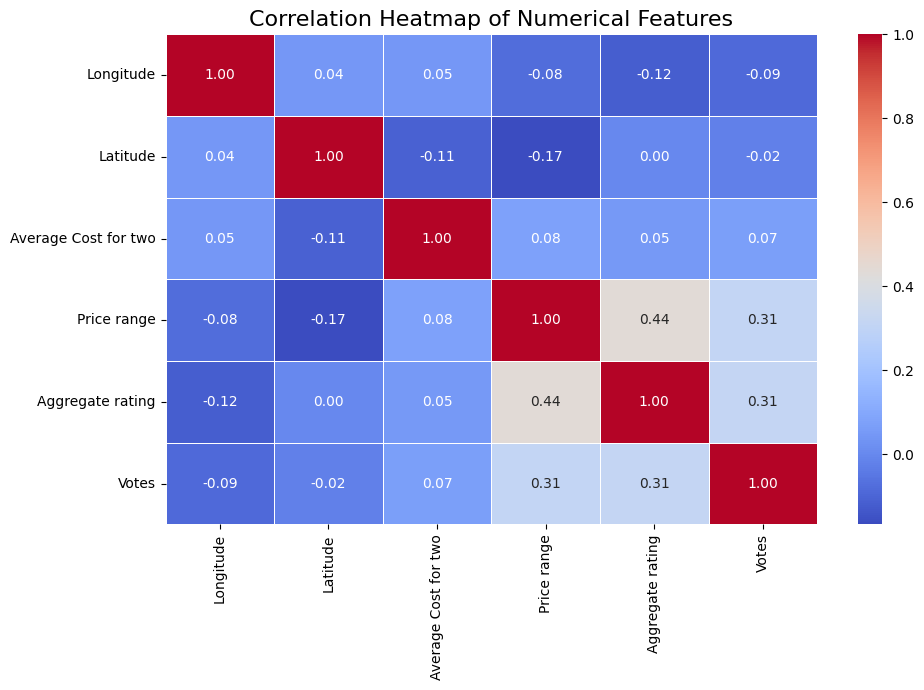

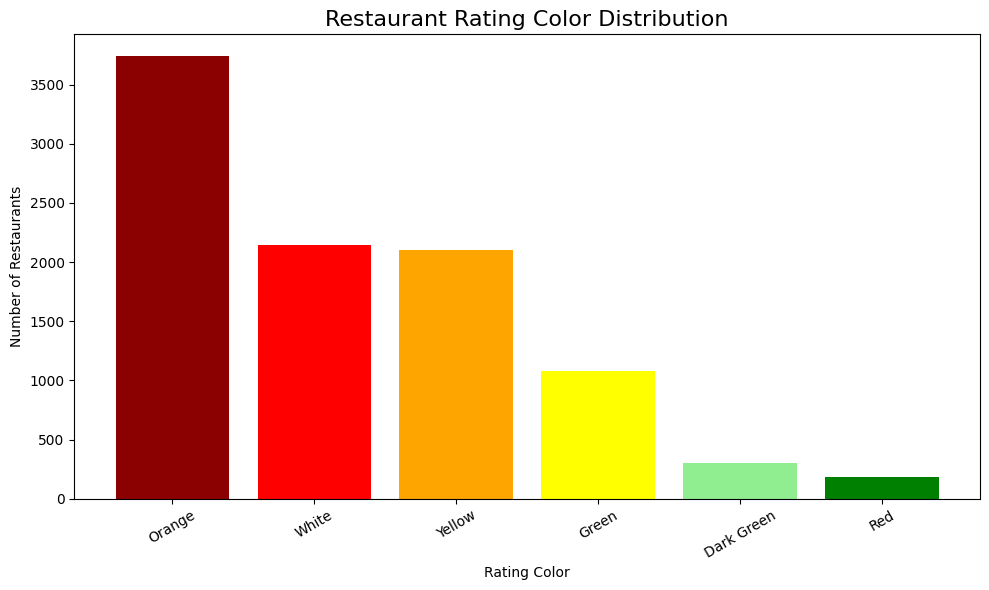

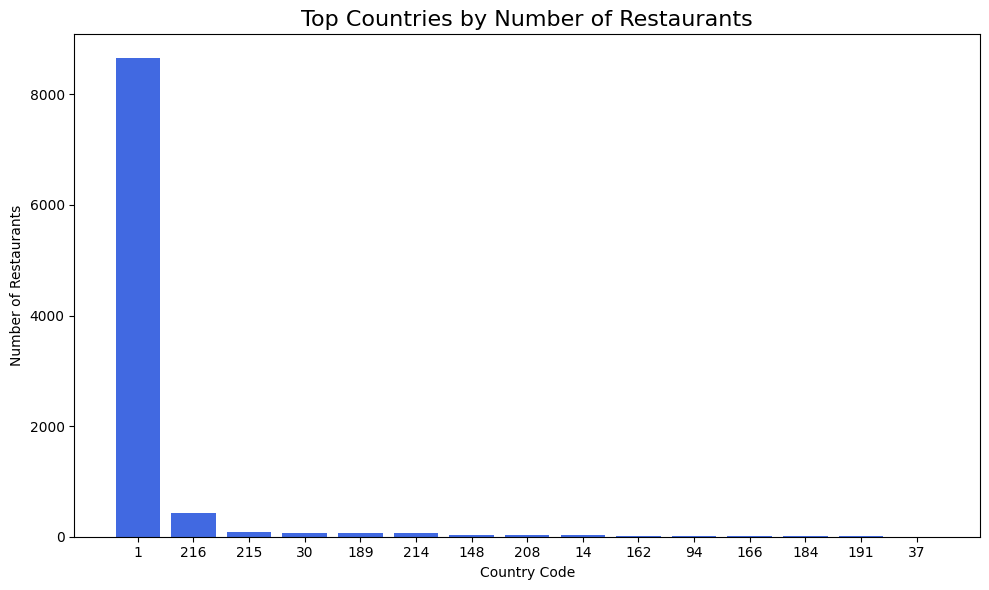

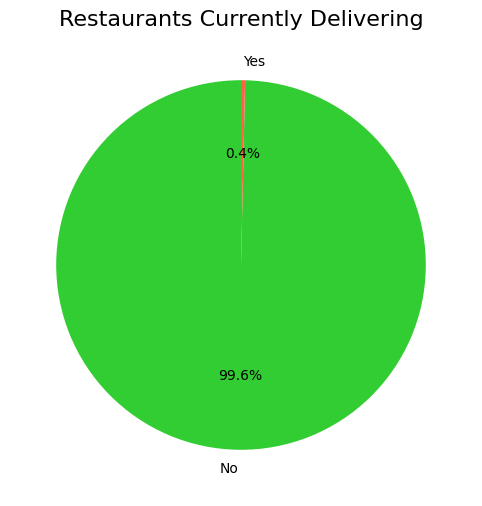

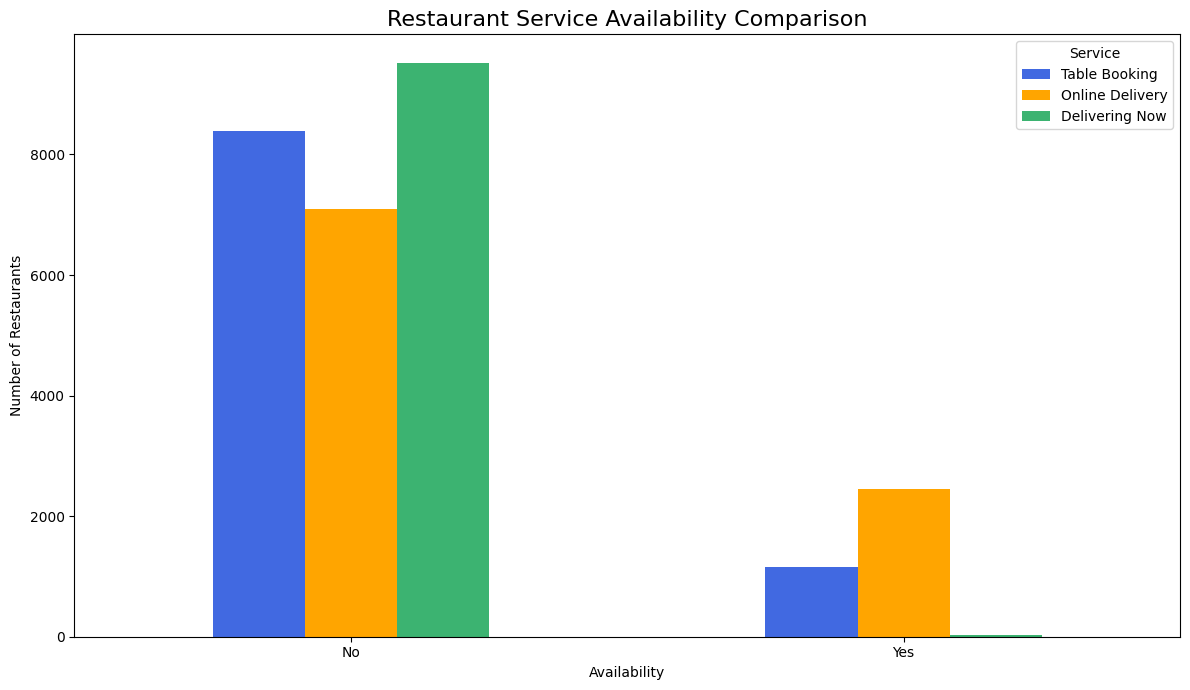

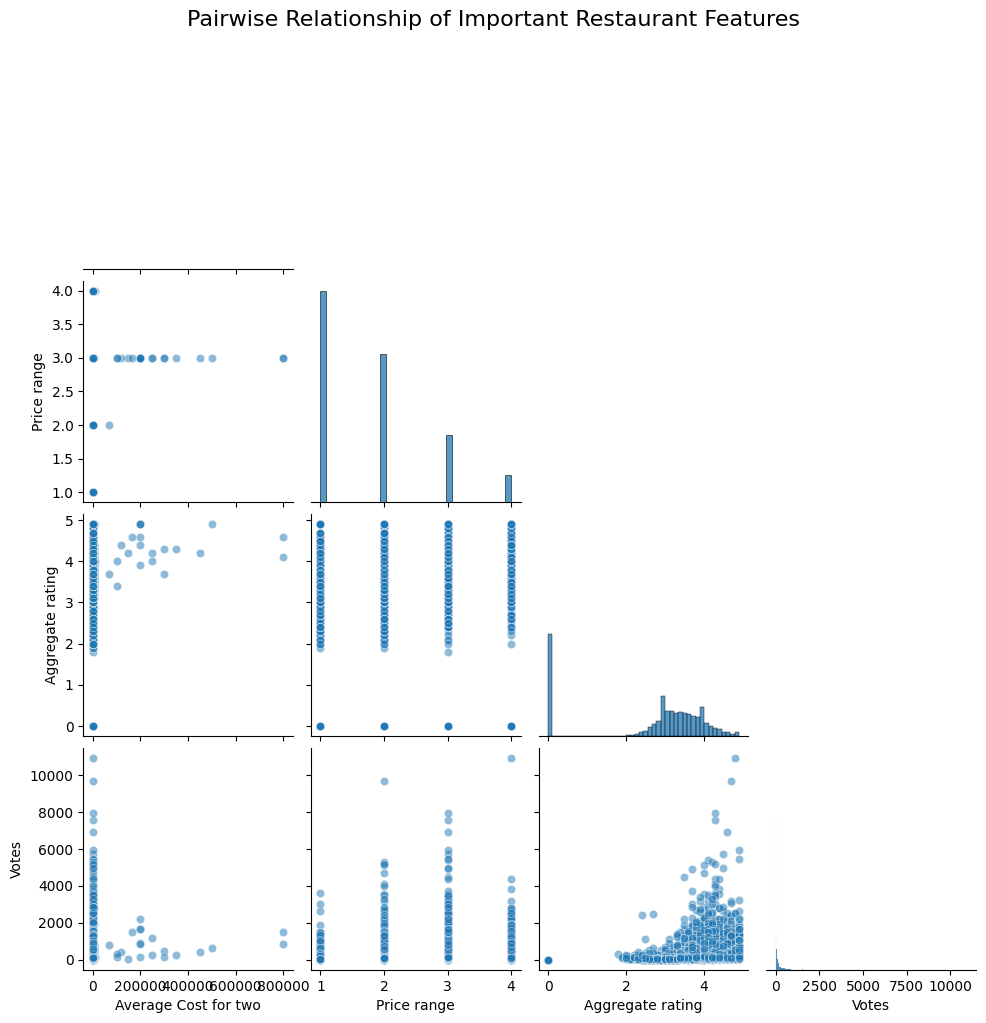

VISUALIZATION ANALYSIS COMPLETED

Dataset Shape: (9551, 21)

Most Common Cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64

Most Common Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

Average Aggregate Rating: 2.67

Average Cost for Two: 1199.21

Total Votes: 1498645


In [13]:
# ============================================================
# 3. Rating Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Aggregate rating"].dropna(),
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Restaurant Aggregate Ratings", fontsize=16)
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()


# ============================================================
# 4. Price Range Distribution
# ============================================================

plt.figure(figsize=(9, 6))

price_counts = df["Price range"].value_counts().sort_index()

plt.bar(
    price_counts.index.astype(str),
    price_counts.values,
    color=["tomato", "gold", "mediumseagreen", "mediumpurple"]
)

plt.title("Number of Restaurants by Price Range", fontsize=16)
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

for i, value in enumerate(price_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


# ============================================================
# 5. Rating Text Distribution
# ============================================================

plt.figure(figsize=(10, 6))

rating_text_counts = df["Rating text"].value_counts()

colors = [
    "red",
    "orange",
    "gold",
    "lightgreen",
    "green",
    "skyblue"
]

plt.bar(
    rating_text_counts.index.astype(str),
    rating_text_counts.values,
    color=colors[:len(rating_text_counts)]
)

plt.title("Restaurant Rating Category Distribution", fontsize=16)
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 6. Table Booking Availability
# ============================================================

plt.figure(figsize=(8, 6))

booking_counts = df["Has Table booking"].value_counts()

plt.pie(
    booking_counts.values,
    labels=booking_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["cornflowerblue", "salmon"]
)

plt.title("Restaurants with Table Booking", fontsize=16)
plt.show()


# ============================================================
# 7. Online Delivery Availability
# ============================================================

plt.figure(figsize=(8, 6))

delivery_counts = df["Has Online delivery"].value_counts()

plt.pie(
    delivery_counts.values,
    labels=delivery_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["mediumseagreen", "tomato"]
)

plt.title("Restaurants with Online Delivery", fontsize=16)
plt.show()


# ============================================================
# 8. Online Delivery vs Average Rating
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Has Online delivery",
    y="Aggregate rating",
    hue="Has Online delivery",
    palette=["salmon", "mediumseagreen"],
    legend=False
)

plt.title("Aggregate Rating vs Online Delivery", fontsize=16)
plt.xlabel("Has Online Delivery")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()


# ============================================================
# 9. Table Booking vs Average Rating
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Has Table booking",
    y="Aggregate rating",
    hue="Has Table booking",
    palette=["skyblue", "orange"],
    legend=False
)

plt.title("Aggregate Rating vs Table Booking", fontsize=16)
plt.xlabel("Has Table Booking")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()


# ============================================================
# 10. Price Range vs Aggregate Rating
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Price range",
    y="Aggregate rating",
    hue="Price range",
    palette="Set2",
    legend=False
)

plt.title("Aggregate Rating by Price Range", fontsize=16)
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()


# ============================================================
# 11. Votes vs Aggregate Rating
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    color="crimson",
    alpha=0.6,
    s=70
)

plt.title("Votes vs Aggregate Rating", fontsize=16)
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()


# ============================================================
# 12. Votes vs Average Cost for Two
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Average Cost for two",
    y="Votes",
    color="darkorange",
    alpha=0.6,
    s=70
)

plt.title("Average Cost for Two vs Votes", fontsize=16)
plt.xlabel("Average Cost for Two")
plt.ylabel("Votes")

plt.tight_layout()
plt.show()


# ============================================================
# 13. Average Cost Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Average Cost for two"].dropna(),
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Average Cost for Two", fontsize=16)
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()


# ============================================================
# 14. Top 15 Cities by Number of Restaurants
# ============================================================

top_cities = df["City"].value_counts().head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_cities.index[::-1],
    top_cities.values[::-1],
    color="teal"
)

plt.title("Top 15 Cities by Number of Restaurants", fontsize=16)
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()


# ============================================================
# 15. Top 15 Localities
# ============================================================

top_localities = df["Locality"].value_counts().head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_localities.index[::-1],
    top_localities.values[::-1],
    color="coral"
)

plt.title("Top 15 Localities by Number of Restaurants", fontsize=16)
plt.xlabel("Number of Restaurants")
plt.ylabel("Locality")

plt.tight_layout()
plt.show()


# ============================================================
# 16. Top 15 Restaurants by Votes
# ============================================================

top_votes = (
    df.groupby("Restaurant Name")["Votes"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_votes.index[::-1],
    top_votes.values[::-1],
    color="steelblue"
)

plt.title("Top 15 Restaurants by Total Votes", fontsize=16)
plt.xlabel("Total Votes")
plt.ylabel("Restaurant Name")

plt.tight_layout()
plt.show()


# ============================================================
# 17. Top 15 Restaurants by Aggregate Rating
# ============================================================

top_rated = (
    df.groupby("Restaurant Name")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_rated.index[::-1],
    top_rated.values[::-1],
    color="mediumvioletred"
)

plt.title("Top 15 Restaurants by Average Rating", fontsize=16)
plt.xlabel("Average Aggregate Rating")
plt.ylabel("Restaurant Name")

plt.tight_layout()
plt.show()


# ============================================================
# 18. Cuisine Frequency
# ============================================================

cuisine_data = (
    df["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 7))

plt.barh(
    cuisine_data.index[::-1],
    cuisine_data.values[::-1],
    color="darkcyan"
)

plt.title("Top 15 Most Common Cuisines", fontsize=16)
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()


# ============================================================
# 19. Rating vs Average Cost
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Average Cost for two",
    y="Aggregate rating",
    hue="Price range",
    palette="viridis",
    alpha=0.7,
    s=80
)

plt.title("Average Cost vs Aggregate Rating", fontsize=16)
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.legend(title="Price Range")

plt.tight_layout()
plt.show()


# ============================================================
# 20. Correlation Heatmap
# ============================================================

numeric_columns = [
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()


# ============================================================
# 21. Rating Color Distribution
# ============================================================

rating_color_counts = df["Rating color"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    rating_color_counts.index.astype(str),
    rating_color_counts.values,
    color=[
        "darkred",
        "red",
        "orange",
        "yellow",
        "lightgreen",
        "green"
    ][:len(rating_color_counts)]
)

plt.title("Restaurant Rating Color Distribution", fontsize=16)
plt.xlabel("Rating Color")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 22. Restaurant Count by Country Code
# ============================================================

country_counts = df["Country Code"].value_counts().head(15)

plt.figure(figsize=(10, 6))

plt.bar(
    country_counts.index.astype(str),
    country_counts.values,
    color="royalblue"
)

plt.title("Top Countries by Number of Restaurants", fontsize=16)
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()


# ============================================================
# 23. Delivering Now Distribution
# ============================================================

delivering_counts = df["Is delivering now"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    delivering_counts.values,
    labels=delivering_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["limegreen", "tomato"]
)

plt.title("Restaurants Currently Delivering", fontsize=16)
plt.show()


# ============================================================
# 24. Combined Business Feature Comparison
# ============================================================

business_features = pd.DataFrame({
    "Table Booking": df["Has Table booking"].value_counts(),
    "Online Delivery": df["Has Online delivery"].value_counts(),
    "Delivering Now": df["Is delivering now"].value_counts()
}).fillna(0)

business_features.plot(
    kind="bar",
    figsize=(12, 7),
    color=["royalblue", "orange", "mediumseagreen"]
)

plt.title("Restaurant Service Availability Comparison", fontsize=16)
plt.xlabel("Availability")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.legend(title="Service")

plt.tight_layout()
plt.show()


# ============================================================
# 25. Pairplot of Important Numerical Features
# ============================================================

pairplot_columns = [
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

sns.pairplot(
    df[pairplot_columns].dropna(),
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.5}
)

plt.suptitle(
    "Pairwise Relationship of Important Restaurant Features",
    y=1.02,
    fontsize=16
)

plt.show()


# ============================================================
# 26. Summary
# ============================================================

print("=" * 70)
print("VISUALIZATION ANALYSIS COMPLETED")
print("=" * 70)

print("\nDataset Shape:", df.shape)

print("\nMost Common Cities:")
print(df["City"].value_counts().head(10))

print("\nMost Common Cuisines:")
print(
    df["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

print("\nAverage Aggregate Rating:",
      round(df["Aggregate rating"].mean(), 2))

print("\nAverage Cost for Two:",
      round(df["Average Cost for two"].mean(), 2))

print("\nTotal Votes:",
      df["Votes"].sum())

## Feature engineering

Dataset Shape:
(9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Missing Values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Target Distribution:
Has Online delivery
No   

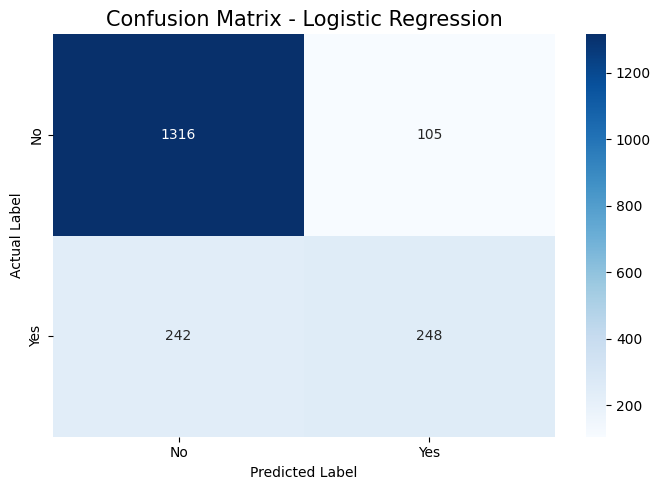


TRAINING: Decision Tree

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1421
         Yes       0.66      0.58      0.62       490

    accuracy                           0.82      1911
   macro avg       0.76      0.74      0.75      1911
weighted avg       0.81      0.82      0.81      1911



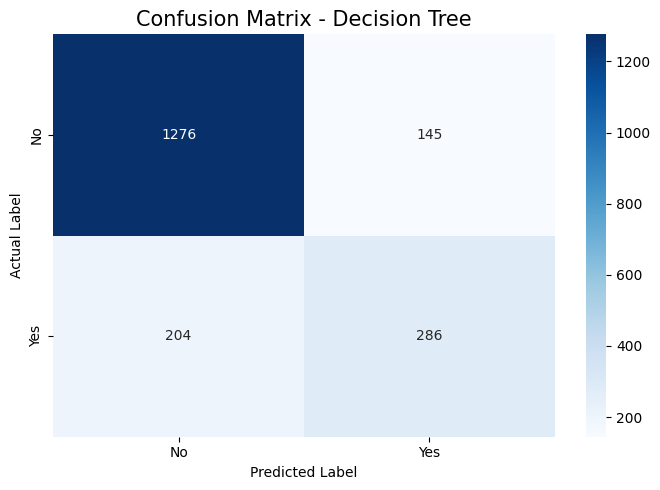


TRAINING: Random Forest

Classification Report:
              precision    recall  f1-score   support

          No       0.75      1.00      0.85      1421
         Yes       0.90      0.02      0.04       490

    accuracy                           0.75      1911
   macro avg       0.82      0.51      0.45      1911
weighted avg       0.79      0.75      0.64      1911



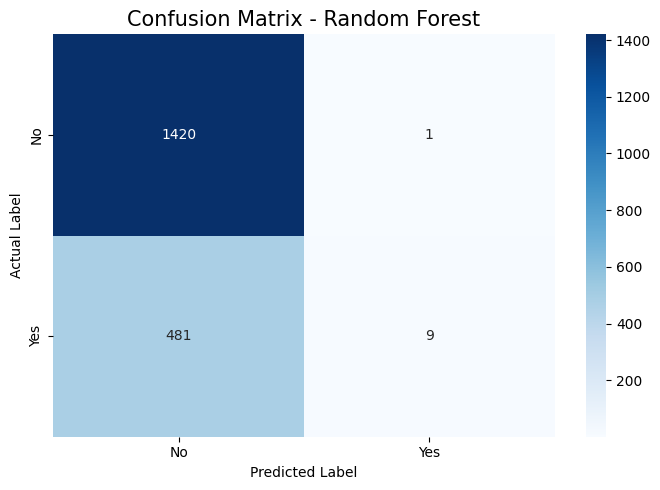


TRAINING: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.92      0.89      1421
         Yes       0.70      0.54      0.61       490

    accuracy                           0.82      1911
   macro avg       0.78      0.73      0.75      1911
weighted avg       0.81      0.82      0.81      1911



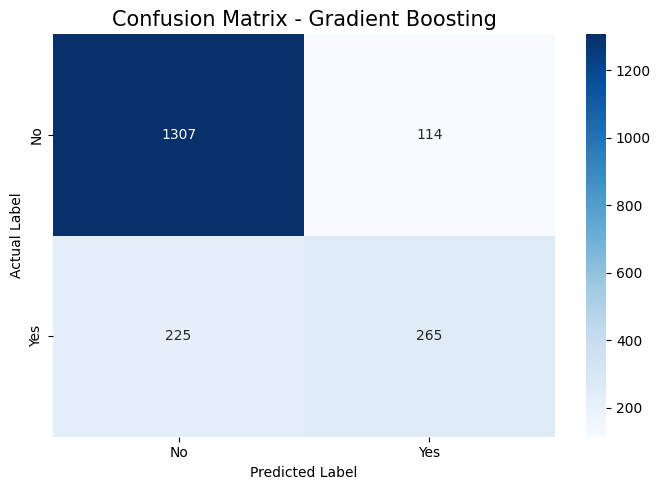


TRAINING: KNN

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.90      0.88      1421
         Yes       0.66      0.58      0.62       490

    accuracy                           0.81      1911
   macro avg       0.76      0.74      0.75      1911
weighted avg       0.81      0.81      0.81      1911



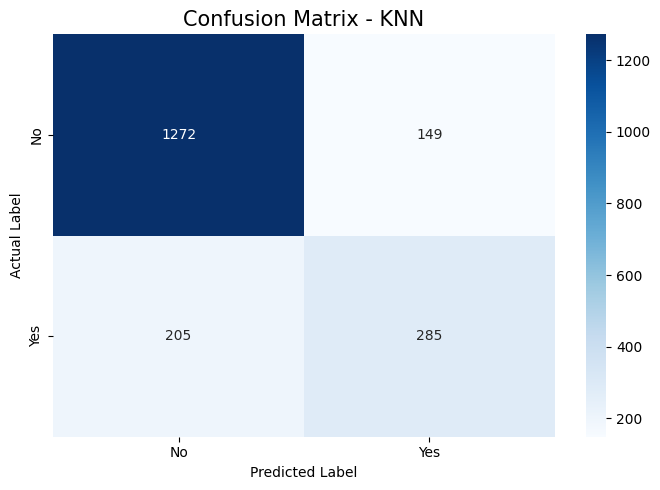


TRAINING: XGBoost

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.91      0.89      1421
         Yes       0.70      0.58      0.64       490

    accuracy                           0.83      1911
   macro avg       0.78      0.75      0.76      1911
weighted avg       0.82      0.83      0.82      1911



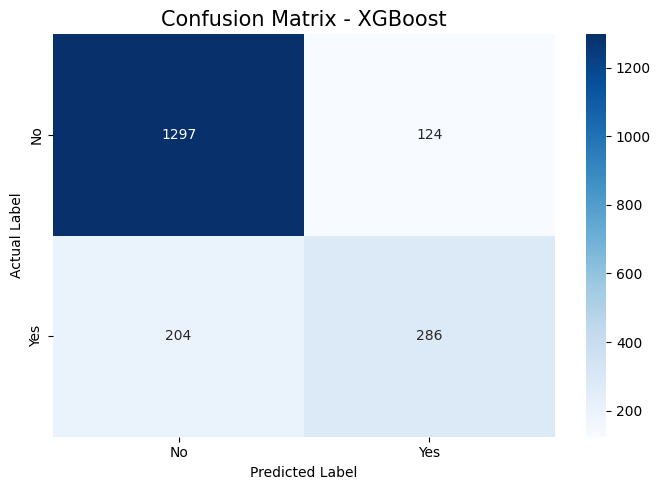


MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,XGBoost,82.84%,69.76%,58.37%,63.56%,0.8833
3,Gradient Boosting,82.26%,69.92%,54.08%,60.99%,0.8721
0,Logistic Regression,81.84%,70.25%,50.61%,58.84%,0.8714
4,KNN,81.48%,65.67%,58.16%,61.69%,0.8537
2,Random Forest,74.78%,90.00%,1.84%,3.60%,0.8523
1,Decision Tree,81.74%,66.36%,58.37%,62.11%,0.8405


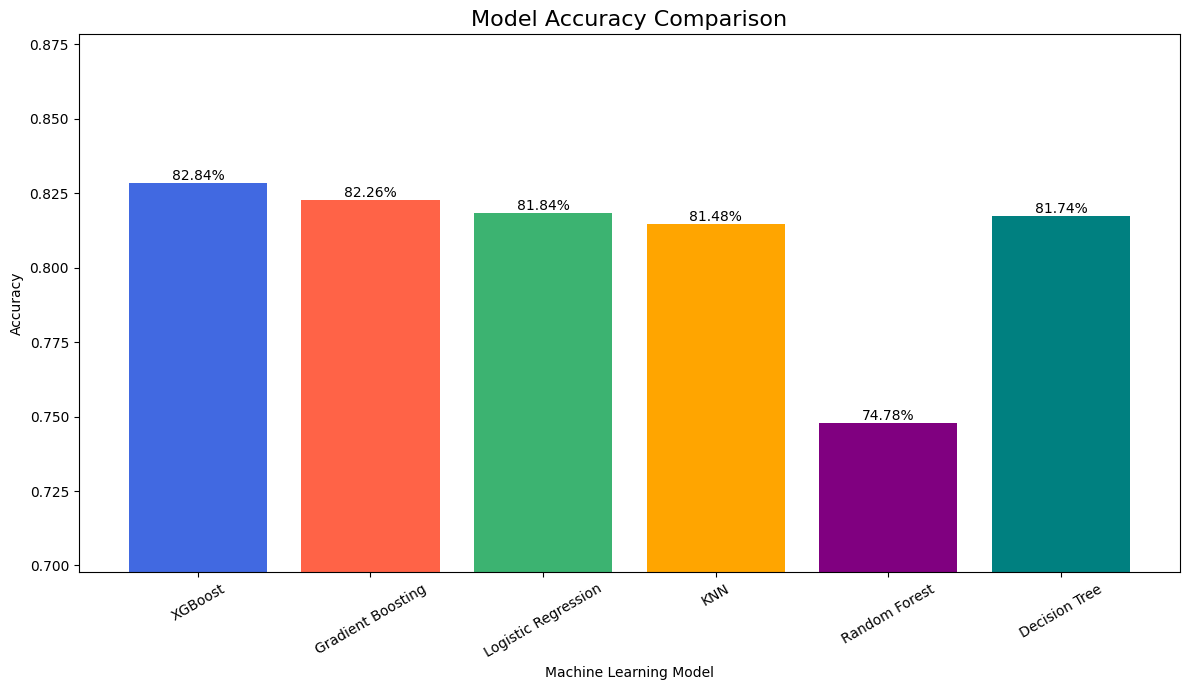

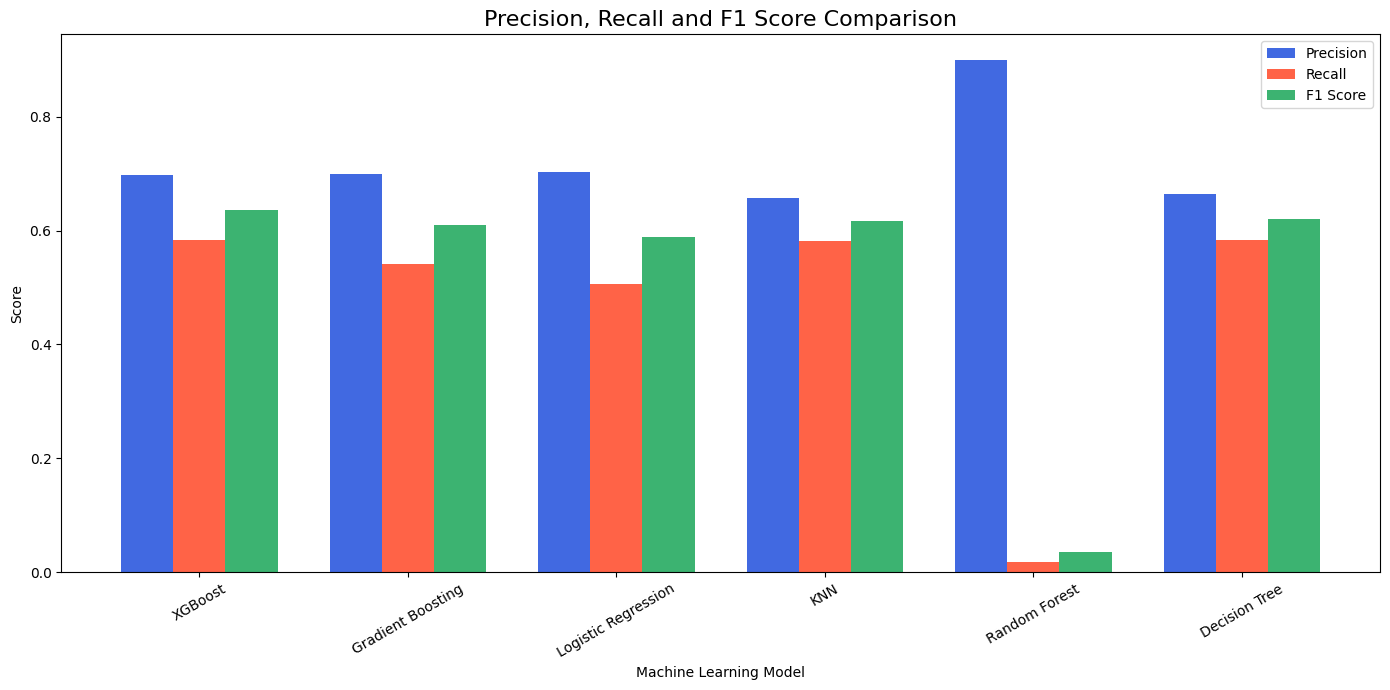

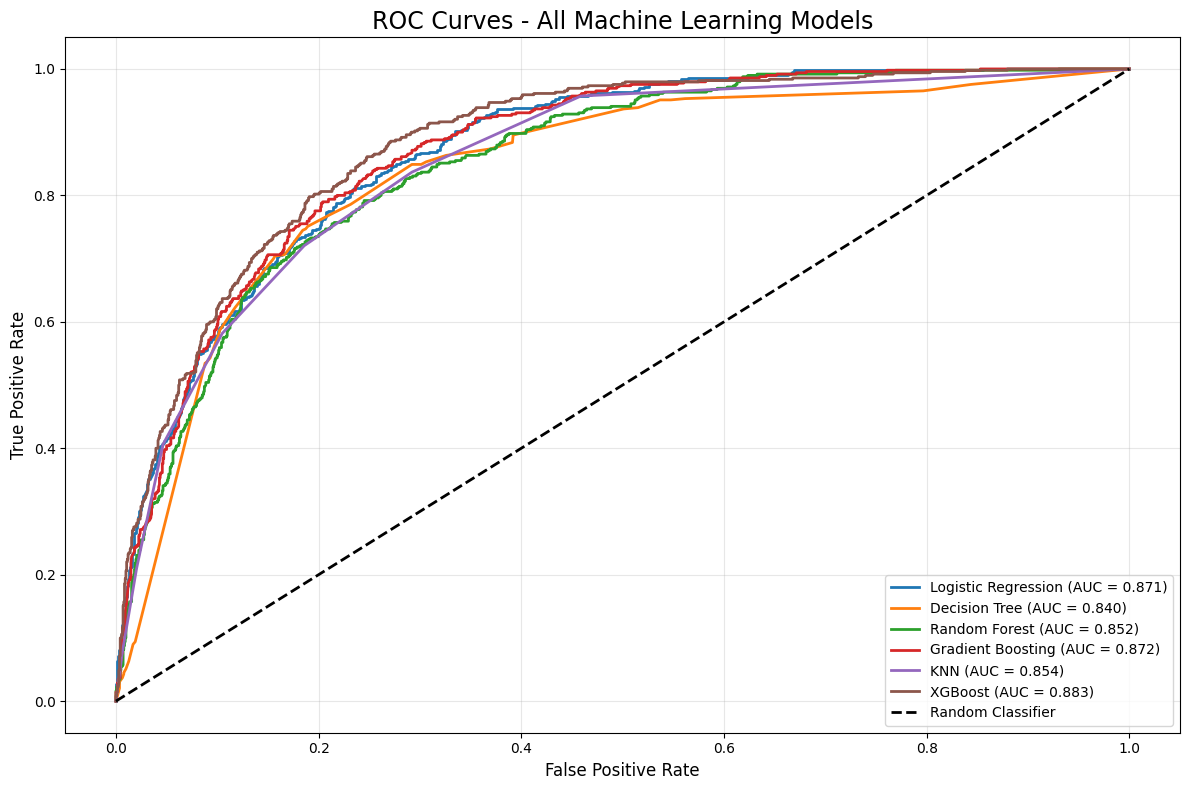

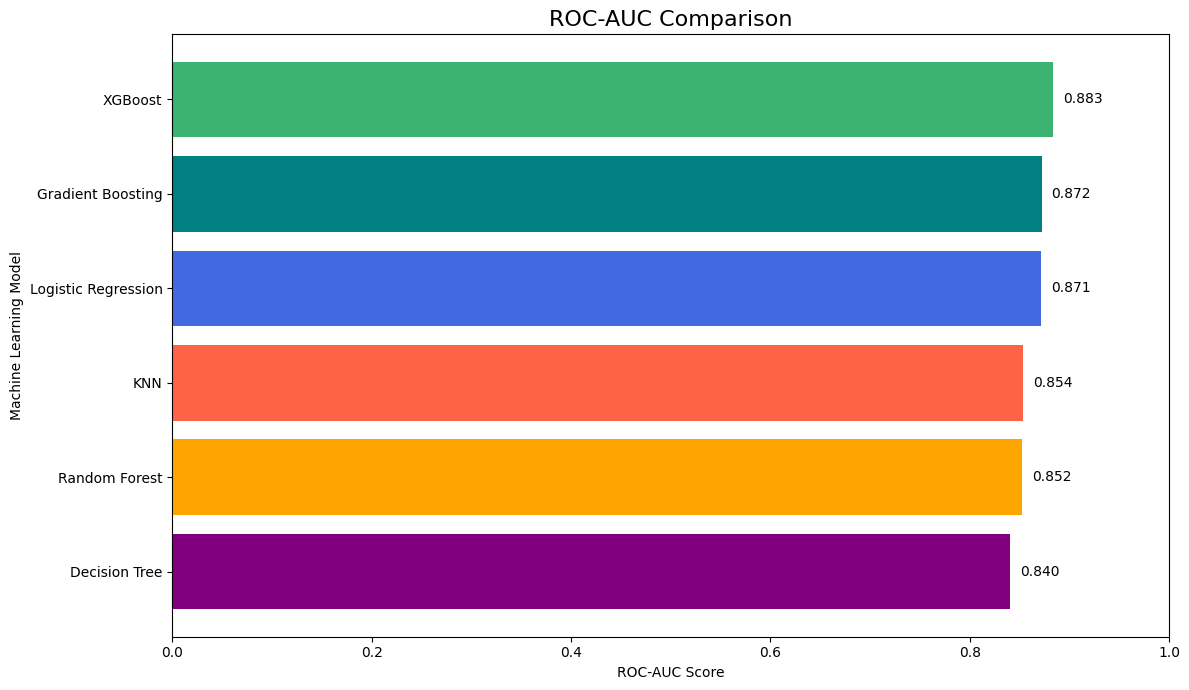


FINAL MODEL RESULTS
              Model  Accuracy  Precision   Recall  F1 Score  ROC AUC
            XGBoost  0.828362   0.697561 0.583673  0.635556 0.883276
  Gradient Boosting  0.822606   0.699208 0.540816  0.609896 0.872096
Logistic Regression  0.818420   0.702550 0.506122  0.588375 0.871363
                KNN  0.814757   0.656682 0.581633  0.616883 0.853728
      Random Forest  0.747776   0.900000 0.018367  0.036000 0.852295
      Decision Tree  0.817373   0.663573 0.583673  0.621064 0.840474

Example Predictions:


,Actual,Predicted
0,No,No
1,Yes,Yes
2,No,No
3,No,No
4,No,No


In [14]:
# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# XGBoost
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# 2. CHECK DATASET
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 3. CREATE A COPY
# ============================================================

data = df.copy()


# ============================================================
# 4. CLEAN COLUMN NAMES
# ============================================================

# Remove accidental spaces from column names
data.columns = data.columns.str.strip()


# ============================================================
# 5. TARGET VARIABLE
# ============================================================

target = "Has Online delivery"

print("\nTarget Distribution:")
print(data[target].value_counts())


# ============================================================
# 6. REMOVE ROWS WHERE TARGET IS MISSING
# ============================================================

data = data.dropna(subset=[target]).copy()


# ============================================================
# 7. LABEL ENCODE TARGET
# ============================================================

# Convert:
# No  -> 0
# Yes -> 1

target_encoder = LabelEncoder()

data[target] = target_encoder.fit_transform(data[target].astype(str))

print("\nTarget Classes:")
print(target_encoder.classes_)

print("\nEncoded Target Distribution:")
print(data[target].value_counts())


# ============================================================
# 8. DEFINE FEATURES AND TARGET
# ============================================================

X = data.drop(target, axis=1)

y = data[target]


# ============================================================
# 9. REMOVE ID / HIGH-CARDINALITY IDENTIFIER COLUMNS
# ============================================================

# Restaurant ID is an identifier and should not be used
# Restaurant Name has extremely high cardinality
# Address / Locality can also create unnecessarily large
# categorical feature spaces.

columns_to_drop = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality Verbose"
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in X.columns
]

X = X.drop(columns=columns_to_drop)

print("\nRemoved Columns:")
print(columns_to_drop)

print("\nRemaining Features:")
print(X.columns.tolist())


# ============================================================
# 10. CONVERT BOOLEAN-LIKE COLUMNS TO STRING
# ============================================================

# These columns are categorical values such as Yes/No.
categorical_boolean_columns = [
    "Has Table booking",
    "Is delivering now",
    "Switch to order menu"
]

for col in categorical_boolean_columns:
    if col in X.columns:
        X[col] = X[col].astype(str)


# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())


# ============================================================
# 12. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 13. NUMERICAL PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 14. CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 15. COLUMN TRANSFORMER
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 16. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


# ============================================================
# 17. TRAIN MODELS
# ============================================================

trained_models = {}

results = []

roc_data = {}


for model_name, model in models.items():

    print("\n" + "=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    # Create pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train
    pipeline.fit(X_train, y_train)

    # Save trained model
    trained_models[model_name] = pipeline

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability predictions
    y_probability = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    # ROC curve values
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    }

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=15
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC AUC": "{:.4f}"
    })
)


# ============================================================
# 19. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=[
        "royalblue",
        "tomato",
        "mediumseagreen",
        "orange",
        "purple",
        "teal"
    ][:len(results_df)]
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=16
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(
    max(0, results_df["Accuracy"].min() - 0.05),
    min(1, results_df["Accuracy"].max() + 0.05)
)

plt.xticks(rotation=30)

for bar, value in zip(
    bars,
    results_df["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 20. PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1 Score"
]

x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(
    x - width,
    results_df["Precision"],
    width,
    label="Precision",
    color="royalblue"
)

plt.bar(
    x,
    results_df["Recall"],
    width,
    label="Recall",
    color="tomato"
)

plt.bar(
    x + width,
    results_df["F1 Score"],
    width,
    label="F1 Score",
    color="mediumseagreen"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=30
)

plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.title(
    "Precision, Recall and F1 Score Comparison",
    fontsize=16
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 21. ROC CURVE - ALL MODELS
# ============================================================

plt.figure(figsize=(12, 8))

for model_name, data_roc in roc_data.items():

    plt.plot(
        data_roc["fpr"],
        data_roc["tpr"],
        linewidth=2,
        label=f"{model_name} (AUC = {data_roc['auc']:.3f})"
    )


# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=17
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. ROC-AUC COMPARISON
# ============================================================

plt.figure(figsize=(12, 7))

auc_sorted = results_df.sort_values(
    "ROC AUC",
    ascending=True
)

bars = plt.barh(
    auc_sorted["Model"],
    auc_sorted["ROC AUC"],
    color=[
        "purple",
        "orange",
        "tomato",
        "royalblue",
        "teal",
        "mediumseagreen"
    ][:len(auc_sorted)]
)

plt.xlabel("ROC-AUC Score")
plt.ylabel("Machine Learning Model")

plt.title(
    "ROC-AUC Comparison",
    fontsize=16
)

plt.xlim(0, 1)

for bar, value in zip(
    bars,
    auc_sorted["ROC AUC"]
):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 23. FINAL MODEL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL RESULTS")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 24. PREDICTION EXAMPLE
# ============================================================

# Example using the first 5 test records
example_predictions = pd.DataFrame({
    "Actual": target_encoder.inverse_transform(
        y_test.iloc[:5].values
    ),
    "Predicted": target_encoder.inverse_transform(
        trained_models[
            results_df.iloc[0]["Model"]
        ].predict(X_test.iloc[:5])
    )
})

print("\nExample Predictions:")
display(example_predictions)